In [1]:
import piplite
await piplite.install("pandas")

import pandas as pd
import matplotlib.pyplot as plt

print("Pandas is working")

Pandas is working


In [2]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.shape

(7043, 21)

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"].isnull().sum()

np.int64(11)

In [9]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

df["TotalCharges"].isnull().sum()

np.int64(0)

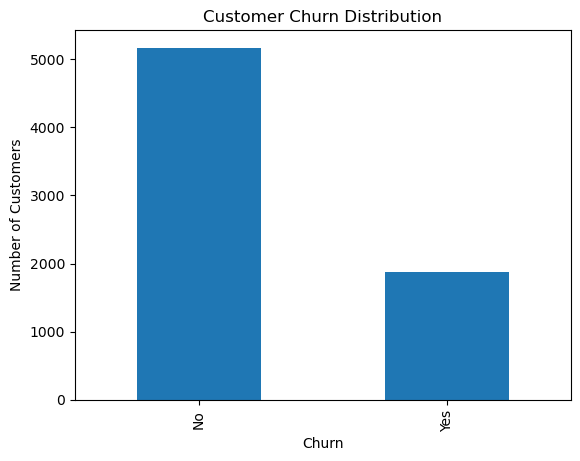

In [10]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
### Observation

The majority of customers did not churn, while a smaller group left the company. This indicates that although customer retention is generally good, there is still a significant number of customers leaving, which the business should investigate.

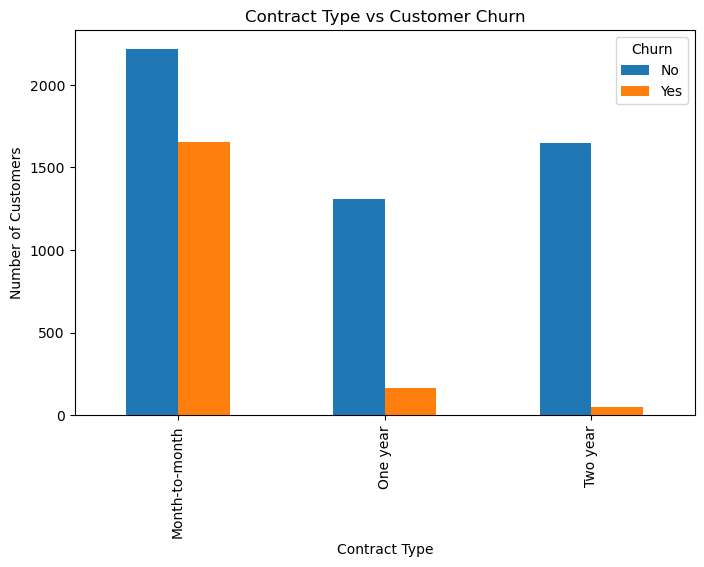

In [11]:
pd.crosstab(df["Contract"], df["Churn"]).plot(kind="bar", figsize=(8,5))

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
### Observation

Customers with month-to-month contracts have the highest number of churn cases. Customers on one-year and two-year contracts are much more likely to remain with the company. This suggests that longer contracts improve customer retention.

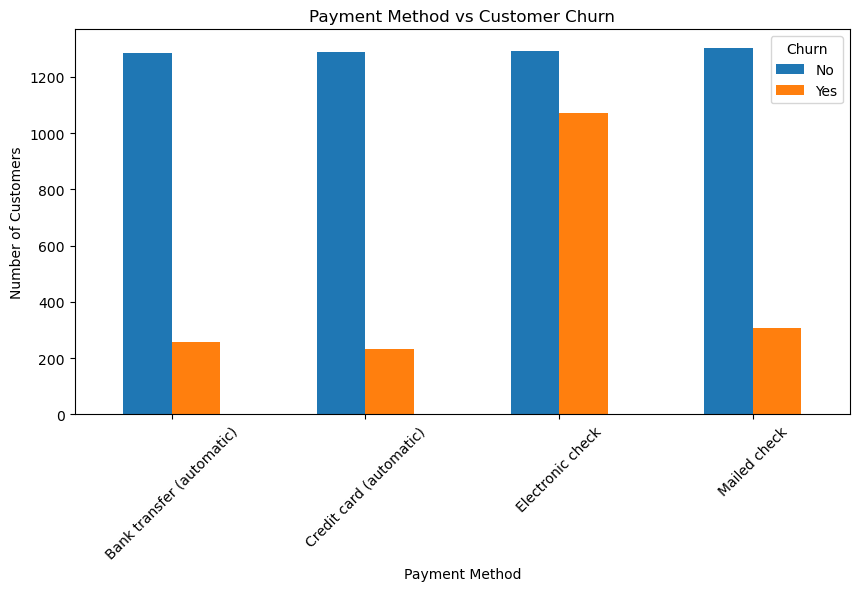

In [12]:
pd.crosstab(df["PaymentMethod"], df["Churn"]).plot(kind="bar", figsize=(10,5))

plt.title("Payment Method vs Customer Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

In [ ]:
### Observation

Customers using electronic check have the highest churn rate compared to other payment methods. Customers using automatic payment methods, such as bank transfer and credit card, tend to stay with the company longer. This suggests that promoting automatic payments could help reduce customer churn.

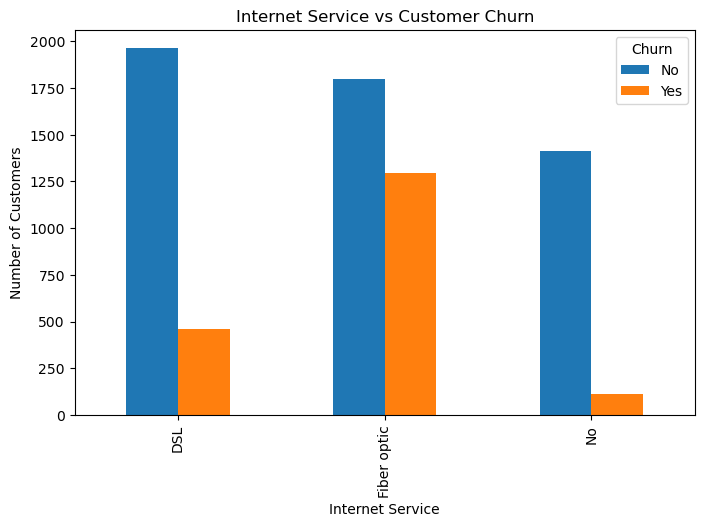

In [13]:
pd.crosstab(df["InternetService"], df["Churn"]).plot(kind="bar", figsize=(8,5))

plt.title("Internet Service vs Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
### Observation

Customers using Fiber optic internet have the highest number of churn cases. Customers using DSL have lower churn, while customers with no internet service have the lowest churn. This suggests that the company should investigate customer satisfaction, pricing, or service quality for Fiber optic users.

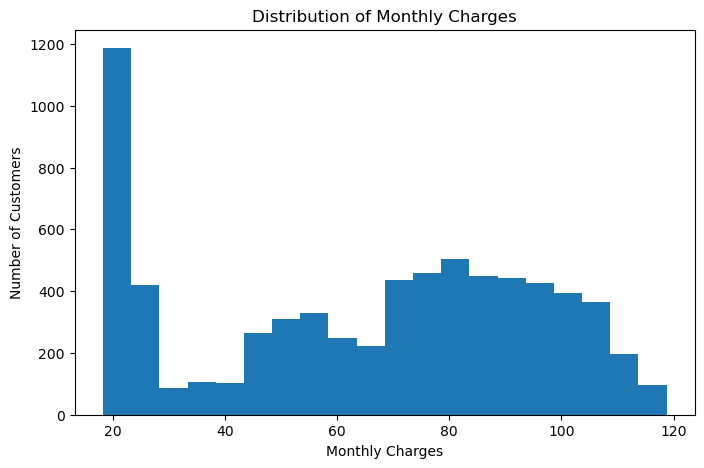

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df["MonthlyCharges"], bins=20)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

### Observation

Most customers pay between R20 and R100 per month. The distribution shows that customers have different pricing plans, which may influence their likelihood of leaving the company.

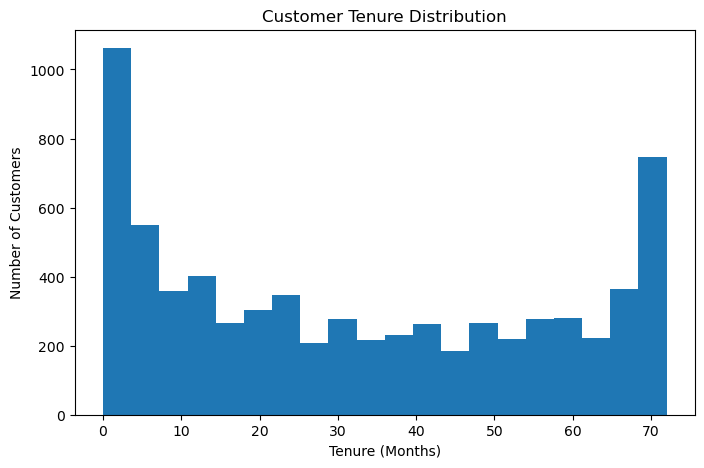

In [15]:
plt.figure(figsize=(8,5))

plt.hist(df["tenure"], bins=20)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
### Observation

Many customers have either recently joined the company or have been customers for a long time. Customers with shorter tenure are generally more likely to churn, while long-term customers are more likely to remain loyal.

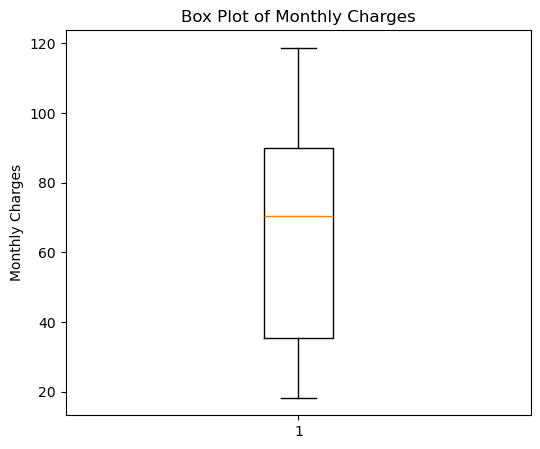

In [16]:
plt.figure(figsize=(6,5))

plt.boxplot(df["MonthlyCharges"])

plt.title("Box Plot of Monthly Charges")
plt.ylabel("Monthly Charges")

plt.show()

### Observation

Most customers have monthly charges within a similar range, although there are some customers with significantly higher charges. Higher monthly charges may contribute to customer churn.


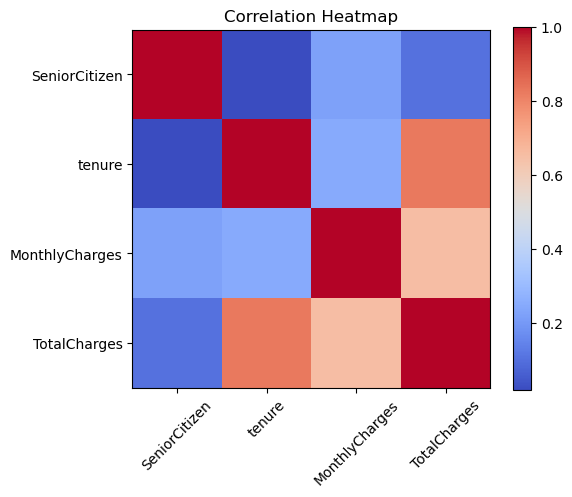

In [17]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

corr = numeric_df.corr()

plt.figure(figsize=(6,5))

plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

### Observation

The heatmap shows the relationships between the numeric variables. Monthly Charges and Total Charges have a positive correlation, while tenure is also positively related to Total Charges because customers who stay longer usually spend more over time.


# Business Insights

## Insight 1
Customers with month-to-month contracts have the highest churn rate, indicating that short-term contracts are associated with lower customer loyalty.

## Insight 2
Customers using electronic check as their payment method are more likely to churn than those using automatic payment methods.

## Insight 3
Fiber optic internet customers show higher churn compared to DSL and customers without internet service.

## Insight 4
Customers with shorter tenure are more likely to leave the company than long-term customers.

## Insight 5
Customers with higher monthly charges appear more likely to churn, suggesting pricing may influence customer retention.

# Recommendations

1. Encourage customers to switch from month-to-month contracts to one-year or two-year contracts by offering discounts and rewards.

2. Promote automatic payment methods by providing incentives such as small monthly discounts.

3. Improve customer satisfaction among Fiber optic users by reviewing service quality and pricing.

4. Develop customer retention programs for new customers during their first six months.

5. Offer loyalty rewards to long-term customers to strengthen retention and reduce churn.

# Conclusion

This analysis identified several key factors contributing to customer churn. Contract type, payment method, internet service, tenure, and monthly charges all influence customer retention. By implementing targeted retention strategies based on these findings, the company can reduce churn, improve customer satisfaction, and increase long-term profitability.